# Random Forest 

L'objectif est d'étudier le fonctionnement des Random Forest.

# 1 - Spambase classification with Random Forest

Pour commencer, on va s'interesser à nouveau au dataset de mails déjà étudiés pour les autres modèles.

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

In [90]:
# chargement du dataset "spambase"
dataspam = np.loadtxt("spambase/spambase.data", delimiter=",")
X = dataspam[:,0:57]
y = dataspam[:,-1]

In [91]:
# séparation des données en données d'entraînement et test
X_train, X_test, Y_train, Y_test = train_test_split(X,y, test_size=0.2,
                                              train_size=0.8)

**Il n'y a pas besoin de normaliser les données pour le Random Forest car les arbres se basent sur l’ordre des valeurs, pas sur leur échelle, autrement dit les arbres ne font pas de calcul de distance.**

In [92]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [94]:
feature_names = [
    "word_freq_make", "word_freq_address", "word_freq_all", "word_freq_3d", "word_freq_our",
    "word_freq_over", "word_freq_remove", "word_freq_internet", "word_freq_order",
    "word_freq_mail", "word_freq_receive", "word_freq_will", "word_freq_people",
    "word_freq_report", "word_freq_addresses", "word_freq_free", "word_freq_business",
    "word_freq_email", "word_freq_you", "word_freq_credit", "word_freq_your",
    "word_freq_font", "word_freq_000", "word_freq_money", "word_freq_hp",
    "word_freq_hpl", "word_freq_george", "word_freq_650", "word_freq_lab",
    "word_freq_labs", "word_freq_telnet", "word_freq_857", "word_freq_data",
    "word_freq_415", "word_freq_85", "word_freq_technology", "word_freq_1999",
    "word_freq_parts", "word_freq_pm", "word_freq_direct", "word_freq_cs",
    "word_freq_meeting", "word_freq_original", "word_freq_project", "word_freq_re",
    "word_freq_edu", "word_freq_table", "word_freq_conference",
    "char_freq_;", "char_freq_(", "char_freq_[", "char_freq_!", "char_freq_$",
    "char_freq_#", "capital_run_length_average",
    "capital_run_length_longest", "capital_run_length_total"
]

importances = clf.feature_importances_
indices_sorted = np.argsort(importances)[::-1]

In [98]:
print("Features triées par importance :")
for idx in indices_sorted[:10]:
    print(f"{feature_names[idx]:35s}  importance = {importances[idx]:.4f}")

Features triées par importance :
char_freq_!                          importance = 0.1143
char_freq_$                          importance = 0.1042
word_freq_remove                     importance = 0.0810
word_freq_free                       importance = 0.0631
capital_run_length_longest           importance = 0.0536
capital_run_length_average           importance = 0.0534
word_freq_your                       importance = 0.0528
capital_run_length_total             importance = 0.0518
word_freq_hp                         importance = 0.0458
word_freq_you                        importance = 0.0402


In [93]:
err_train = 1 - accuracy_score(Y_train, clf.predict(X_train))
err_test = 1- accuracy_score(Y_test, clf.predict(X_test))
print(f"Erreur de train: {err_train*100:.2f}%")
print(f"Erreur de test: {err_test*100:.2f}%")

Erreur de train: 0.05%
Erreur de test: 3.37%


On constate un très faible taux d'erreur sur les données d'entraînement (<1%), on pourrait donc s'attendre à ce que le modèle sur-apprenne cependant on a également un faible taux d'erreur sur les données de test (<4%).

Comparons ces scores à ceux du modèle SVM:

In [87]:
# on normalise les données pour le SVM car ce modèle est basé sur des calculs de distance.
sc = StandardScaler(with_mean=True, with_std=True)
sc = sc.fit(X_train)
X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

clfker = SVC(kernel="rbf")
clfker.gamma = 0.1
clfker.C = 10
clfker.fit(X_train, Y_train)
err_train = 1 - accuracy_score(Y_train, clfker.predict(X_train))
err_test = 1- accuracy_score(Y_test, clfker.predict(X_test))
print(f"Erreur de train: {err_train*100:.2f}%")
print(f"Erreur de test: {err_test*100:.2f}%")

Erreur de train: 0.84%
Erreur de test: 7.60%


On constate un taux d'erreur toujours faible pour les données d'entraînement, mais assez proche de 1. Ce qui nous intéresse le plus c'est que les données de test ont perdu casiment 5 points (selon le découpage des données) sur le taux d'erreur.  
On peut conclure que pour ce dataset, le modèle kernel SVM semble moins robuste que le modèle Random Forest.

On va tout de même tester le modèle Random Forest sur des donnés normalisées pour voir la différence:

In [88]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [89]:
err_train = 1 - accuracy_score(Y_train, clf.predict(X_train))
err_test = 1- accuracy_score(Y_test, clf.predict(X_test))
print(f"Erreur de train: {err_train*100:.2f}%")
print(f"Erreur de test: {err_test*100:.2f}%")

Erreur de train: 0.05%
Erreur de test: 3.91%


On constate qu'on obtient sensiblement les mêmes résultats, ce qui confirme le fait qu'il est inutile de normaliser les données pour le Random Forest. C'est logique car le principe même de ce modèle fait qu'il n'y a pas besoin de normaliser les données.

# 2 - Tuning the max_features hyperparameter

L'hyperparamètre "max_features" est crucial pour la performance du modèle. Ce paramètre contrôle le nombre de features qui sont aléatoirement selectionnées pour séparer chaque noeud de l'arbre de décision.  
La valeur par défaut proposé par scikit-lean est √d, avec d: nombre de features du dataset.  
On va s'intéresser à l'impact de ce paramètre sur le modèle.

In [90]:
digit = load_digits()
X = digit.data
y = digit.target
n_instances , n_features = X.shape

In [91]:
print(f"Exemple de feature (ce sont toutes les mêmes):\n {digit.feature_names[0]}")

Exemple de feature (ce sont toutes les mêmes):
 pixel_0_0


Les features de ce dataset sont des pixels. Oui, on peut dire qu’intuitivement toutes les features sont pertinentes, mais certaines le sont beaucoup plus que d’autres, par exemple celles aux centres/ éloignés des bords.

On entraîne le modèle Random Forest selon différentes valeurs de max_features afin de comparer leur performances.

In [92]:
n_replications = 10
vect = np.arange(1,32,1)
list_features = range(1, n_features +1, 2)
err_train = []
err_test = []
for k in list_features:
    clf = RandomForestClassifier(n_estimators=k)
    l_err_train = []
    l_err_test = []
    for i in range(n_replications):
        X_train , X_test , Y_train , Y_test = train_test_split(
            X, y, test_size =0.2)
        clf.fit(X_train, Y_train)
        l_err_train.append(1 - accuracy_score(Y_train, clf.predict(X_train)))
        l_err_test.append(1 - accuracy_score(Y_test, clf.predict(X_test)))
    err_train.append(l_err_train)
    err_test.append(l_err_test)

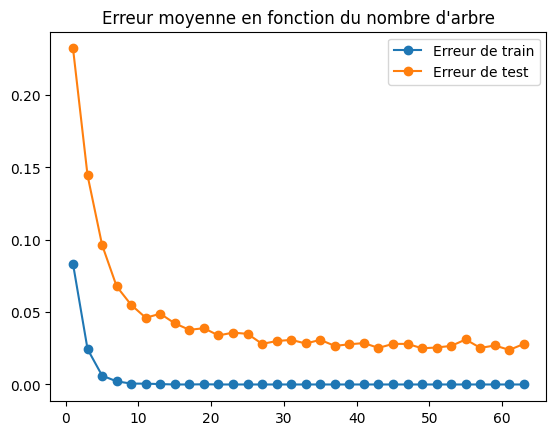

In [93]:
plt.plot(list_features, [np.mean(l) for l in err_train], 'o-', label="Erreur de train")
plt.plot(list_features, [np.mean(l) for l in err_test], 'o-', label="Erreur de test")
plt.legend()
plt.title("Erreur moyenne en fonction du nombre d'arbre")
plt.show()

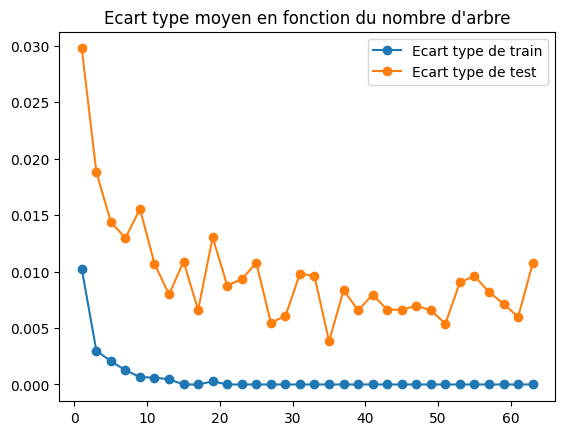

In [94]:
plt.plot(list_features, [np.std(l) for l in err_train], 'o-', label="Ecart type de train")
plt.plot(list_features, [np.std(l) for l in err_test], 'o-', label="Ecart type de test")
plt.legend()
plt.title("Ecart type moyen en fonction du nombre d'arbre")
plt.show()

On constate que le le taux d'erreur descend sous les 10% à partir de 10 abres mais remonte très vite, finlement il est minimum pour n = 35 avec un taux d'erreur inférieur à 5%.

Le taux d'erreur diminue en ajoutant des arbres, ce qui réduit la variance du modèle car les arbres se corrigent entre eux. Cependant, lorsqu'on ajoute trop d'arbres, d'abord les temps de calcul augmente, mais aussi la forêt va commencer à sur-apprendre le bruit du jeu de données, ce qui fait remonter le taux d'erreur sur les données nouvelles (le taux d'erreur sur les données d'entraînement lui n'augmente pas).

# 3 - Measuring the importance of features 

On s'intéresse désormais à l'importance du nombre de features du jeu de données. Pour rappel, l'importance d'une feature calculée comme la diminution moyenne des impuretés (ex: impureté de Gini).  
On se base donc sur cette impureté pour évaluer la performance d'une feature dans l'optique futur de faire une sélection de features.

In [163]:
X, y = make_classification(n_samples =1000 , n_features =20, 
                           n_informative =5, n_redundant =0)

In [164]:
print(f"nombre de features du dataset: {y.shape[0]}")

nombre de features du dataset: 1000


On entraîne un Random Forest sur l'ensemble des features 

In [165]:
clf = RandomForestClassifier(n_estimators=200)
X_train, X_test, Y_train, Y_test = train_test_split(X,y, test_size=0.2,
                                              train_size=0.8)
clf.fit(X_train, Y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [166]:
err_train = 1 - accuracy_score(Y_train, clf.predict(X_train))
err_test = 1- accuracy_score(Y_test, clf.predict(X_test))
print(f"Erreur de train: {err_train*100:.2f}%")
print(f"Erreur de test: {err_test*100:.2f}%")

Erreur de train: 0.00%
Erreur de test: 7.00%


In [171]:
importances = clf.feature_importances_

In [173]:
# liste d'indices des features du plus au moins importatn
indices_sorted = np.argsort(importances)[::-1] 
print(indices_sorted)

top_k = 10 
top_features = indices_sorted[:top_k]
top_importances = importances[top_features]

print(f"Ranking of features by importance")
for idx, imp in zip(top_features, top_importances):
    print(f"Feature {idx} — importance = {imp:.4f}")

[13 18  1 11  3  9  0  7 12  2 16  8  5  6  4 14 19 17 15 10]
Ranking of the features by importance
Feature 13 — importance = 0.1497
Feature 18 — importance = 0.1331
Feature 1 — importance = 0.0960
Feature 11 — importance = 0.0955
Feature 3 — importance = 0.0752
Feature 9 — importance = 0.0331
Feature 0 — importance = 0.0319
Feature 7 — importance = 0.0319
Feature 12 — importance = 0.0317
Feature 2 — importance = 0.0316


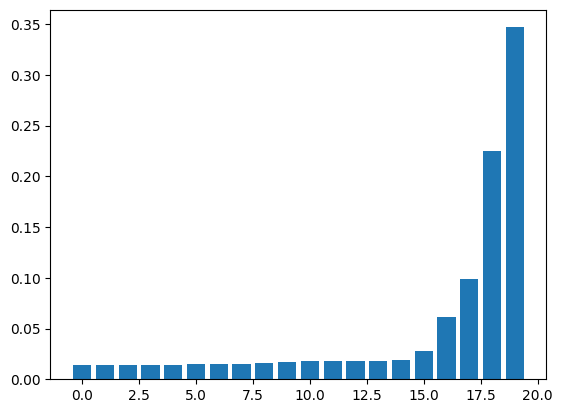

In [152]:
plt.bar(np.arange(20), importances);

Les 5 dernières barres du barplot correspondant aux 5 informative features: ce sont les features qui vont prendre les décisions car elles ont l'impureté de Gini la plus grande. On visualise bien ici le paramètre "n_informative =5".